In [5]:
from pywfn.readers import LogReader
from pywfn.bondorder import piDH,piSH,mayer,piDM
import matplotlib.pyplot as plt
import numpy as np
# plt.style.use('science')
from PIL import Image

# 计算丁二烯的扫描键级
- 二面角
- DH
- Mayer

二面角的范围[-180,180]
需要计算两个键和两个自由价
|键级|自由价|
|---|---|
|5-1|5|
|1-3|3|

In [44]:
# 计算数据
angles=np.arange(36)*10
Dorders=np.zeros(shape=(36,2))
Morders=np.zeros(shape=(36,2))
BondLgs=np.zeros(shape=(36,2))
bonds=[
    [5,1],[1,3]
]
for i in range(36):
    path=f'D:\BaiduSyncdisk\gFile\scans\dingerxi\dingerxi_scanAngle\\f{i+1}.log'
    reader=LogReader(path)
    mol=reader.mol

    # π键键级
    for j,(a,b) in enumerate(bonds):
        Dcaler=piDM.Calculator(mol)
        Mcaler=mayer.Calculator(mol)
        Dorder=Dcaler.calculate(mol.atom(a),mol.atom(b))
        Morder=Mcaler.calculate(mol.atom(a),mol.atom(b))
        BondLg=mol.get_bond(a,b).length

        Dorders[i,j]=Dorder
        Morders[i,j]=Morder
        BondLgs[i,j]=BondLg
np.save('课题数据/丁二烯pi键级.npy',Dorders)
np.save('课题数据/丁二烯Mayer键级.npy',Morders)
np.save('课题数据/丁二烯键长.npy',BondLgs)

# 轨道挑选法计算丁二烯扫描键级

In [47]:
from pywfn.bondorder import piSH

In [55]:
SHorder13=[]
for i in range(36):
    path=f'D:\BaiduSyncdisk\gFile\scans\dingerxi\dingerxi_scanAngle\\f{i+1}.log'
    reader=LogReader(path)
    mol=reader.mol
    caler=piSH.Calculator(mol)
    orders=caler.calculate(mol.atom(1),mol.atom(3))
    SHorder13.append(sum(orders))

Text(0, 0.5, '$\\pi$ Bond Order')

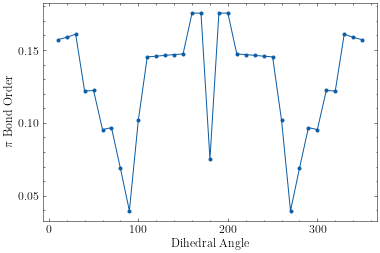

In [59]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({
    "font.size":20, #此处必须添加此句代码方可改变标题字体大小
})
ax.plot(angles[1:],np.array(SHorder13)[1:],marker='.')
ax.set_xlabel('Dihedral Angle')
ax.set_ylabel('$\pi$ Bond Order')

In [60]:
fig.savefig('课题图片/丁二烯挑选法π键级.jpg',bbox_inches='tight',dpi=300)

# 联苯扫描图像
需要计算5个键级和四个自由价
|bond orders|free valences|
|---|---|
|12-3|3|
|3-2|2|
|2-1|1|
|1-6|6|

为了完成C3和C6自由价的计算，还需要计算`3-4`，`6-5`的键级

In [6]:
# 计算数据
bonds=[
    [12,3],[3,2],[2,1],[1,6],[3,4],[6,5]
]
Horders=np.zeros(shape=(36,6)) #36个分子6个键
Morders=np.zeros(shape=(36,6))
BondLgs=np.zeros(shape=(36,6))

for i in range(36):
    path=f"D:\BaiduSyncdisk\gFile\scans\lianben\lianben_scanAngle\\f{i+1}.log"
    reader=LogReader(path)
    mol=reader.mol
    # π键键级
    Hcaler=piDM.Calculator(mol)
    Mcaler=mayer.Calculator(mol)
    for j,(a,b) in enumerate(bonds):
        Horder=Hcaler.calculate(mol.atom(a),mol.atom(b))
        Morder=Mcaler.calculate(mol.atom(a),mol.atom(b))
        BondLg=mol.get_bond(a,b).length
        Horders[i,j]=Horder
        Morders[i,j]=Morder
        BondLgs[i,j]=BondLg
np.save('课题数据/联苯pi键级.npy',Horders)
np.save('课题数据/联苯Mayer键级.npy',Morders)
np.save('课题数据/联苯键长.npy',BondLgs)

In [2]:
import numpy as np
Ps=np.random.rand(10,5,5)
S=np.random.rand(5,5)

In [ ]:
# 三维矩阵乘法